In [26]:
# Clean All SV(somatic+germline)CNV and SV scaled-chromosome analysis script
# This workflow rescales CNV and SV positions onto a 0-1 chromosome axis
# so events from chromosomes of different sizes can be compared directly.
# It then asks whether gains/losses or SVs cluster near telomeres,
# near centromeres, or in interstitial regions.

In [27]:
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(ggplot2)
  library(ggpubr)
  library(ggforce)
  library(scales)
})

In [28]:
# --------------------------------------------------
# Paths to the folders
# --------------------------------------------------
data_dir <- "/home/mjehangir/telomere-sv-analysis_backup/data/"
setwd(data_dir)

arm_file <- "/home/mjehangir/chm13_chrs_arms/cytoBandMapped.bed"
telomere_file <- "chm13v2.0_telomere.bed.txt"
sv_file <- "SVs_merged_all_samples_SVs_v7.txt"

In [29]:
# --------------------------------------------------
# Helpers function
# --------------------------------------------------
sv_cols <- c("DEL" = "blue", "DUP" = "red", "INS" = "green4", "INV" = "orange", "BND" = "pink")
region_fill <- c(centromere = "khaki", interstitial = "lightblue", telomere = "lightgreen")
my_comparisons <- list(
  c("centromere", "interstitial"),
  c("centromere", "telomere"),
  c("interstitial", "telomere")
)

In [30]:
# --------------------------------------------------
# Load chromosome arm and telomere annotations
# --------------------------------------------------
# These annotations define the p arm, q arm, centromere,
# and chromosome-end telomere intervals used for scaling.
df_arms <- read.delim(arm_file, header = TRUE)
t2t_telomere <- read.csv(telomere_file, header = TRUE, sep = "\t")

colnames(df_arms) <- c("chr", "start", "end", "band", "stain")
colnames(t2t_telomere) <- c("chr", "start", "end")

# Label telomere intervals by chromosome end.
t2t_telomere <- t2t_telomere %>%
  group_by(chr) %>%
  arrange(start, .by_group = TRUE) %>%
  mutate(
    telomere_arm = case_when(
      row_number() == 1 ~ "p",
      row_number() == n() ~ "q",
      TRUE ~ NA_character_
    )
  ) %>%
  ungroup()

In [31]:
# Collapse chm13 cytobands into broad structural regions.
df_arms <- df_arms %>%
  mutate(
    arm = case_when(
      stain == "acen" ~ "centromere",
      grepl("^p", band) ~ "p",
      TRUE ~ "q"
    ),
    size = end - start
  ) %>%
  group_by(chr, arm) %>%
  summarise(
    total_size = sum(size),
    start = min(start),
    end = max(end),
    .groups = "drop"
  )

# combined annotation table.
t2t_merged_data <- bind_rows(
  df_arms %>% select(chr, arm, start, end),
  t2t_telomere %>% mutate(arm = paste0(telomere_arm, "_telomere")) %>% select(chr, arm, start, end)
) %>%
  arrange(chr, start)

In [32]:
# --------------------------------------------------
# SV analysis on scaled chromosomes
# --------------------------------------------------
sv_data <- read.csv(sv_file, sep = "\t", header = TRUE) %>%
  mutate(
    start = as.numeric(start),
    end = as.numeric(end)
  )

# Map each SV to the same normalized chromosome coordinate system.
sv_scaled <- sv_data %>%
  select(-any_of("arm")) %>%
  left_join(df_arms %>% filter(arm == "p") %>% select(chr, start_p = start), by = "chr") %>%
  left_join(df_arms %>% filter(arm == "q") %>% select(chr, end_q = end), by = "chr") %>%
  left_join(df_arms %>% filter(arm == "centromere") %>% select(chr, centromere_start = start), by = "chr") %>%
  mutate(
    midpoint = (start + end) / 2,
    scaled_pos = (midpoint - start_p) / (end_q - start_p),
    centromere_pos = if_else(
      !is.na(centromere_start) & !is.na(start_p) & !is.na(end_q),
      (centromere_start - start_p) / (end_q - start_p),
      NA_real_
    )
  ) %>%
  filter(!is.na(scaled_pos)) %>%
  mutate(chr = factor(chr, levels = paste0("chr", c(1:22, "X", "Y")))) %>%
  filter(!is.na(chr))

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `end = as.numeric(end)`.
Caused by warning:
! NAs introduced by coercion”


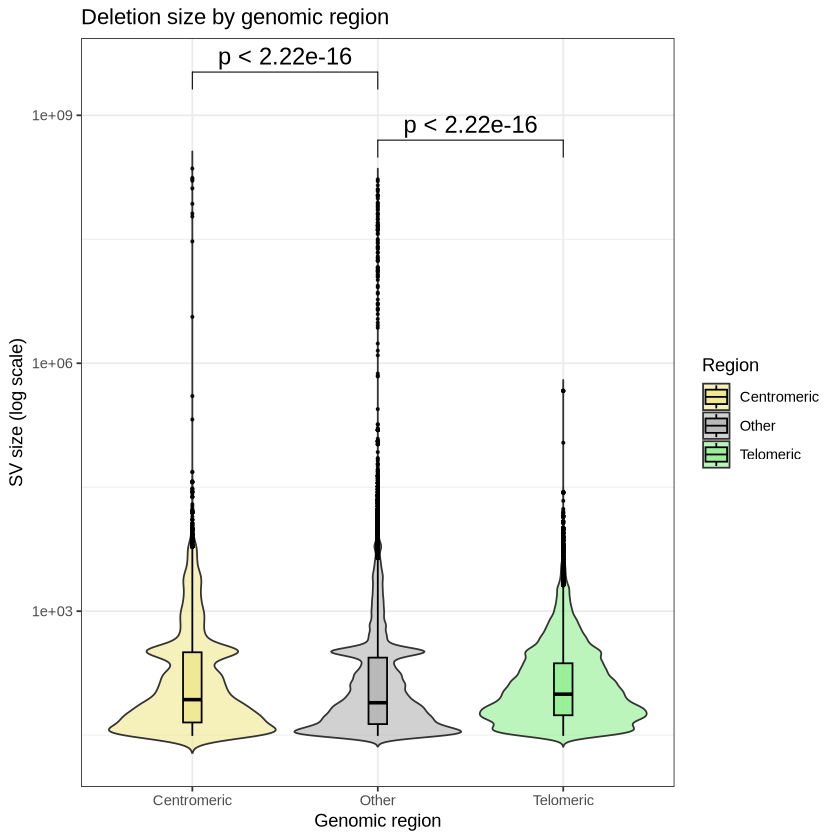

In [33]:
# 5. DEL size by broad chromosome region
#  test whether deletions near telomeres or centromeres differ in size from other deletions.
sv_del <- sv_scaled %>%
  filter(type == "DEL") %>%
  mutate(
    region_group = case_when(
      scaled_pos <= 0.03 | scaled_pos >= 0.97 ~ "Telomeric",
      scaled_pos > 0.45 & scaled_pos < 0.55 ~ "Centromeric",
      TRUE ~ "Other"
    )
  )

p_del_size <- ggplot(sv_del, aes(x = region_group, y = size, fill = region_group)) +
  geom_violin(alpha = 0.6, scale = "width", trim = FALSE) +
  geom_boxplot(width = 0.1, outlier.size = 0.5, alpha = 0.8, color = "black") +
  scale_y_log10() +
  scale_fill_manual(values = c(
    "Telomeric" = "lightgreen",
    "Centromeric" = "khaki",
    "Other" = "gray70"
  )) +
  stat_compare_means(
    method = "wilcox.test",
    comparisons = list(c("Telomeric", "Other"), c("Centromeric", "Other")),
    label.y.npc = "top",
    size = 5
  ) +
  labs(
    title = "Deletion size by genomic region",
    x = "Genomic region",
    y = "SV size (log scale)",
    fill = "Region"
  ) +
  theme_bw()

print(p_del_size)

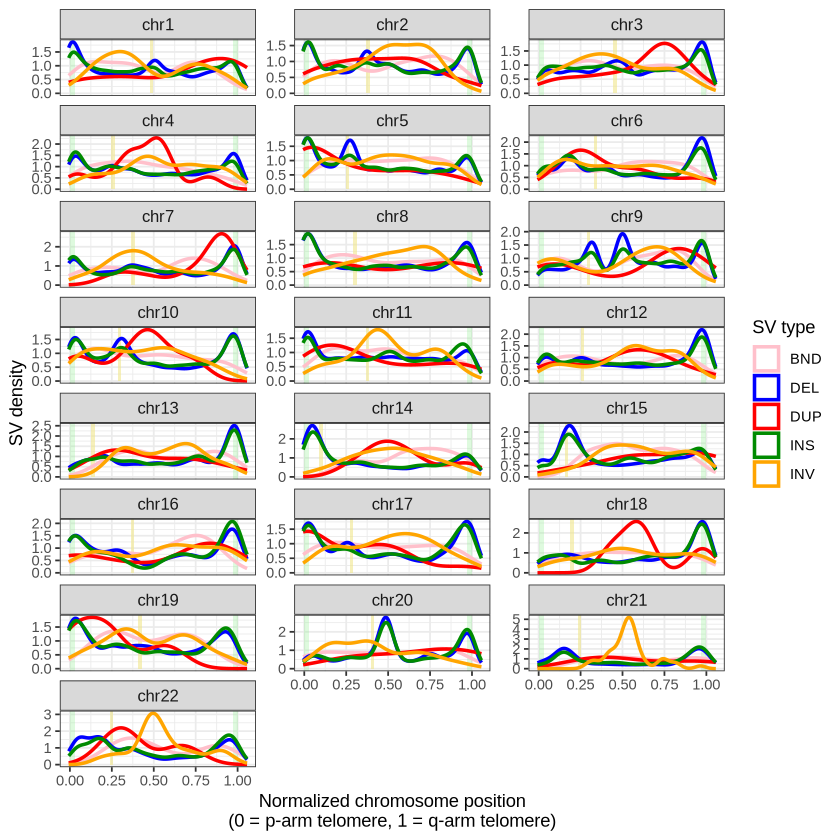

In [16]:
# 6. SV density per chromosome with telomere and centromere shading
# show whether breakpoint density accumulates near chromosome ends or centromeres.
peritel_pct <- 0.03
cent_data <- sv_scaled %>%
  distinct(chr, centromere_pos) %>%
  filter(!is.na(centromere_pos))

p_sv_density_chr <- ggplot(sv_scaled, aes(x = scaled_pos, color = type)) +
  annotate("rect", xmin = 0, xmax = peritel_pct, ymin = -Inf, ymax = Inf,
           fill = "lightgreen", alpha = 0.3) +
  annotate("rect", xmin = 1 - peritel_pct, xmax = 1, ymin = -Inf, ymax = Inf,
           fill = "lightgreen", alpha = 0.3) +
  geom_rect(
    data = cent_data,
    aes(xmin = centromere_pos - 0.01, xmax = centromere_pos + 0.01, ymin = 0, ymax = Inf),
    inherit.aes = FALSE,
    fill = "khaki",
    alpha = 0.6
  ) +
  geom_density(adjust = 1, linewidth = 1, fill = NA) +
  scale_color_manual(values = sv_cols) +
  facet_wrap(~ chr, scales = "free_y", ncol = 3) +
  labs(
    x = "Normalized chromosome position\n(0 = p-arm telomere, 1 = q-arm telomere)",
    y = "SV density",
    color = "SV type"
  ) +
  theme_bw() +
  theme(strip.text = element_text(size = 10))

print(p_sv_density_chr)

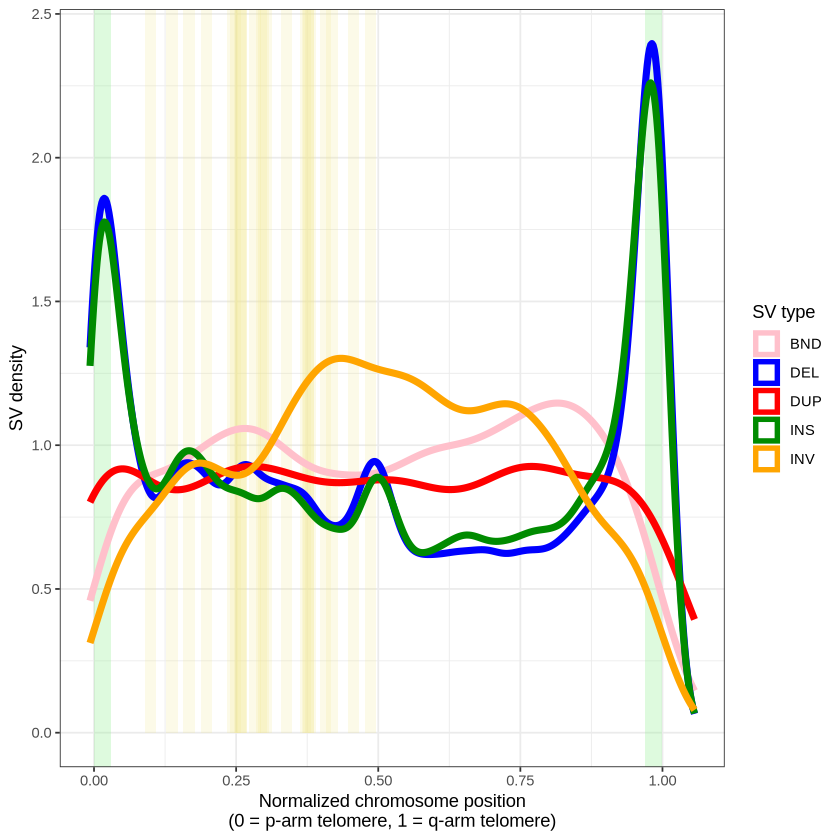

In [17]:
# 7. Whole-genome SV density across scaled chromosomes
# summarize positional clustering across the full genome.
p_sv_density_all <- ggplot(sv_scaled, aes(x = scaled_pos, color = type)) +
  annotate("rect", xmin = 0, xmax = peritel_pct, ymin = -Inf, ymax = Inf,
           fill = "lightgreen", alpha = 0.3) +
  annotate("rect", xmin = 1 - peritel_pct, xmax = 1, ymin = -Inf, ymax = Inf,
           fill = "lightgreen", alpha = 0.3) +
  geom_rect(
    data = cent_data,
    aes(xmin = centromere_pos - 0.01, xmax = centromere_pos + 0.01, ymin = 0, ymax = Inf),
    inherit.aes = FALSE,
    fill = "khaki",
    alpha = 0.2
  ) +
  geom_density(adjust = 1, linewidth = 2, fill = NA) +
  scale_color_manual(values = sv_cols) +
  labs(
    x = "Normalized chromosome position\n(0 = p-arm telomere, 1 = q-arm telomere)",
    y = "SV density",
    color = "SV type"
  ) +
  theme_bw()

print(p_sv_density_all)

In [18]:
# --------------------------------------------------
# Region-based SV enrichment analysis
# --------------------------------------------------
# Define broad genomic compartments and compare SV density per Mb.
sv_categorized <- sv_scaled %>%
  mutate(
    region = case_when(
      scaled_pos <= 0.03 | scaled_pos >= 0.97 ~ "telomere",
      abs(scaled_pos - centromere_pos) < 0.05 ~ "centromere",
      TRUE ~ "interstitial"
    )
  )

region_lengths <- sv_categorized %>%
  distinct(chr, start_p, end_q, centromere_start) %>%
  mutate(
    chr_length = end_q - start_p,
    telo_length = chr_length * 0.03 * 2,
    centro_length = chr_length * 0.05,
    interstitial_length = chr_length - telo_length - centro_length
  ) %>%
  summarise(
    telomere = sum(telo_length),
    centromere = sum(centro_length),
    interstitial = sum(interstitial_length),
    .groups = "drop"
  ) %>%
  pivot_longer(everything(), names_to = "region", values_to = "length_bp") %>%
  mutate(length_mb = length_bp / 1e6)

sv_counts <- sv_categorized %>%
  filter(region %in% c("centromere", "interstitial", "telomere")) %>%
  mutate(
    region = factor(region, levels = c("centromere", "interstitial", "telomere")),
    type = factor(type, levels = c("DEL", "DUP", "INS", "INV", "BND"))
  ) %>%
  group_by(filename, region, type) %>%
  summarise(sv_count = n(), .groups = "drop") %>%
  left_join(region_lengths, by = "region") %>%
  mutate(count_per_mb = sv_count / length_mb)

Warning message:
“Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes.”
Warning message:
“Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes.”
Warning message:
“Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes.”
Warning message in max(data$density, na.rm = TRUE):
“no non-missing arguments to max; returning -Inf”
Warning message:
“Computation failed in `stat_ydensity()`.
Caused by error in `$<-.data.frame`:
! replacement has 1 row, data has 0”
Warning message in wilcox.test.default(c(0.0137987183799354, 0.0482955143297739, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.0137987183799354, 0.0482955143297739, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.003488440

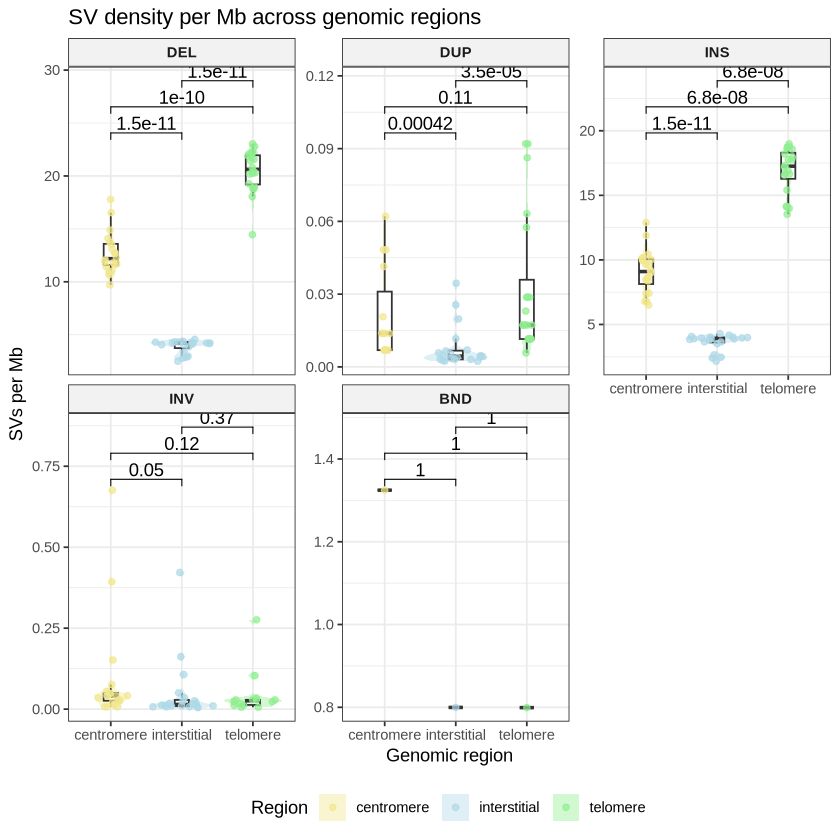

In [19]:
# 8. SV density per Mb across regions
# main statistical comparison of telomeric, centromeric,
# and interstitial enrichment after correcting for region length.
p_region_density <- ggplot(sv_counts, aes(x = region, y = count_per_mb, fill = region)) +
  geom_violin(alpha = 0.4, color = NA) +
  geom_boxplot(width = 0.2, fill = "white", outlier.shape = NA) +
  geom_sina(aes(color = region), alpha = 0.7, size = 1.5) +
  stat_compare_means(
    comparisons = my_comparisons,
    method = "wilcox.test",
    label = "p.format"
  ) +
  facet_wrap(~ type, nrow = 2, ncol = 3, scales = "free_y") +
  scale_fill_manual(values = region_fill) +
  scale_color_manual(values = region_fill) +
  labs(
    x = "Genomic region",
    y = "SVs per Mb",
    fill = "Region",
    color = "Region",
    title = "SV density per Mb across genomic regions"
  ) +
  theme_bw() +
  theme(
    strip.background = element_rect(fill = "grey95"),
    strip.text = element_text(face = "bold"),
    legend.position = "bottom"
  )

print(p_region_density)

In [20]:
# Optional: print Wilcoxon results table.
p_table <- compare_means(
  count_per_mb ~ region,
  data = sv_counts,
  group.by = "type",
  method = "wilcox.test"
)
print(p_table)

# A tibble: 15 × 9
   type  .y.          group1   group2        p    p.adj p.format p.signif method
   <fct> <chr>        <chr>    <chr>     <dbl>    <dbl> <chr>    <chr>    <chr> 
 1 DEL   count_per_mb centrom… inter… 1.45e-11 2.20e-10 1.5e-11  ****     Wilco…
 2 DEL   count_per_mb centrom… telom… 1.02e-10 1.20e- 9 1.0e-10  ****     Wilco…
 3 DEL   count_per_mb interst… telom… 1.45e-11 2.20e-10 1.5e-11  ****     Wilco…
 4 DUP   count_per_mb centrom… inter… 4.16e- 4 3.3 e- 3 0.00042  ***      Wilco…
 5 DUP   count_per_mb centrom… telom… 1.11e- 1 6.7 e- 1 0.11104  ns       Wilco…
 6 DUP   count_per_mb interst… telom… 3.55e- 5 3.2 e- 4 3.5e-05  ****     Wilco…
 7 INS   count_per_mb centrom… inter… 1.45e-11 2.20e-10 1.5e-11  ****     Wilco…
 8 INS   count_per_mb centrom… telom… 6.79e- 8 7.5 e- 7 6.8e-08  ****     Wilco…
 9 INS   count_per_mb interst… telom… 6.79e- 8 7.5 e- 7 6.8e-08  ****     Wilco…
10 INV   count_per_mb centrom… inter… 4.96e- 2 3.5 e- 1 0.04962  *        Wilco…
11 INV   

In [21]:
# --------------------------------------------------
# Chromosome-specific regional densities
# --------------------------------------------------
# This keeps region lengths chromosome-specific for per-chromosome comparisons.
region_lengths_chr <- sv_categorized %>%
  distinct(chr, start_p, end_q) %>%
  mutate(
    chr_length = end_q - start_p,
    telo_length = chr_length * 0.03 * 2,
    centro_length = chr_length * 0.05,
    interstitial_length = chr_length - telo_length - centro_length
  ) %>%
  select(chr, telo_length, centro_length, interstitial_length) %>%
  pivot_longer(
    cols = c(telo_length, centro_length, interstitial_length),
    names_to = "region",
    values_to = "length_bp"
  ) %>%
  mutate(
    region = case_when(
      region == "telo_length" ~ "telomere",
      region == "centro_length" ~ "centromere",
      region == "interstitial_length" ~ "interstitial",
      TRUE ~ region
    ),
    length_mb = length_bp / 1e6
  )

sv_counts_chr <- sv_categorized %>%
  filter(region %in% c("centromere", "interstitial", "telomere")) %>%
  group_by(filename, chr, region, type) %>%
  summarise(sv_count = n(), .groups = "drop") %>%
  left_join(region_lengths_chr, by = c("chr", "region")) %>%
  mutate(count_per_mb = sv_count / length_mb)

Warning message:
“Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes.”
Warning message:
“Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes.”
Warning message:
“Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes.”
Warning message in max(data$density, na.rm = TRUE):
“no non-missing arguments to max; returning -Inf”
Warning message:
“Computation failed in `stat_ydensity()`.
Caused by error in `$<-.data.frame`:
! replacement has 1 row, data has 0”
Warning message:
“Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes.”
Warning message:
“Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment p

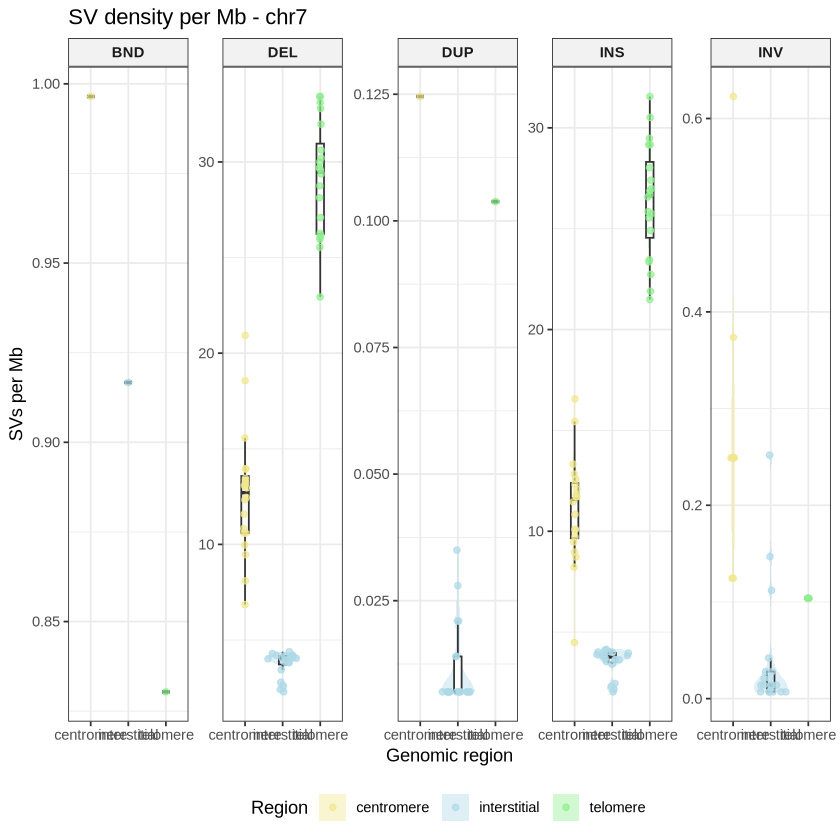

In [25]:
# Helper function for one chromosome.
plot_chr <- function(chr_name) {
  data_sub <- sv_counts_chr %>% filter(chr == chr_name)

  ggplot(data_sub, aes(x = region, y = count_per_mb, fill = region)) +
    geom_violin(alpha = 0.4, color = NA) +
    geom_boxplot(width = 0.2, fill = "white", outlier.shape = NA) +
    geom_sina(aes(color = region), alpha = 0.7, size = 1.5) +
    facet_wrap(~ type, nrow = 1, scales = "free_y") +
    scale_fill_manual(values = region_fill) +
    scale_color_manual(values = region_fill) +
    labs(
      title = paste0("SV density per Mb - ", chr_name),
      x = "Genomic region",
      y = "SVs per Mb",
      fill = "Region",
      color = "Region"
    ) +
    theme_bw() +
    theme(
      strip.background = element_rect(fill = "grey95"),
      strip.text = element_text(face = "bold"),
      legend.position = "bottom"
    )
}

# Example:
 print(plot_chr("chr7"))